# 14 Optuna 하이퍼파라미터 튜닝 (XGBoost)

13장에서 **변수 중요도**를 본 XGBoost를, type(E·C)별로 **Optuna**로 튜닝해 검증 13주 **MAPE**를 개선할 수 있는지 확인합니다.

## 왜 하는가

- 08·10장은 **고정 하이퍼파라미터** XGBoost — type마다 최적 구조가 다를 수 있음
- **Optuna(TPE)** 로 탐색 공간을 자동 탐색 → 수작업 grid 대비 효율적
- 튜닝 전·후 MAPE 비교로 **type별 개선 여지** 정량화

| 항목 | 내용 |
|------|------|
| 모델 | XGBoost 패널 (type 내 family 합침) |
| 목적함수 | 검증 13주 **MAPE** 최소화 |
| 탐색 | `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `reg_alpha/lambda` |
| baseline | 08·13장과 동일 고정 파라미터 |

**선행:** 02, 03, 13 | **산출:** `xgboost_optuna_tuning_results.csv`

### ⓪ 환경 설정

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'code' else NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'code'))

from utils.paths import DATA_PROCESSED
from utils.splits import VAL_WEEKS, TRAIN_WEEK_MAX
from utils.device import device_label
from utils.hyperparameter_tuning import (
    DEFAULT_XGB_PARAMS, panel_val_mape, tune_xgb_all_types,
)

N_TRIALS = 30  # type당 Optuna trial 수 (늘리면 정확도↑, 시간↑)

print('Torch device:', device_label())
feat_df = pd.read_parquet(DATA_PROCESSED / 'df_weekly_features.parquet')
types = sorted(feat_df['type'].unique())
print('types:', types)
print('학습 <=', TRAIN_WEEK_MAX, '| 검증:', VAL_WEEKS)
print('baseline params:', DEFAULT_XGB_PARAMS)
print('n_trials per type:', N_TRIALS)


Torch device: cuda (NVIDIA GeForce RTX 5090, 32GB)
types: ['C', 'E']
학습 <= 201707 | 검증: [201708, 201709, 201710, 201711, 201712, 201713, 201714, 201715, 201716, 201717, 201718, 201719, 201720]
baseline params: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'objective': 'reg:squarederror', 'random_state': 42, 'n_jobs': -1}
n_trials per type: 30


### ① baseline MAPE (튜닝 전)

In [2]:
baseline_rows = []
for t in types:
    m = panel_val_mape(feat_df, t, None)
    baseline_rows.append({'type': t, 'baseline_mape': round(m, 4)})
baseline_df = pd.DataFrame(baseline_rows)
print(baseline_df.to_string(index=False))


type  baseline_mape
   C        26.5127
   E        59.7967


### ② Optuna 튜닝 — type별 validation MAPE 최소화

type마다 독립 study. 패널 전체를 한 번 학습하고 검증 13주 예측 MAPE를 목적함수로 사용합니다.

In [3]:
results = tune_xgb_all_types(feat_df, types, n_trials=N_TRIALS)
display(results)


,type,baseline_mape,tuned_mape,improvement_pct,n_trials,best_n_estimators,best_max_depth,best_learning_rate,best_subsample,best_colsample_bytree,best_min_child_weight,best_reg_alpha,best_reg_lambda
0,C,26.5127,21.3961,19.30,30,550,4,0.027467,0.704846,0.848229,4,0.127981,0.069392
1,E,59.7967,41.7838,30.12,30,200,5,0.010095,0.998407,0.712347,6,9.868745,0.009337


### ③ baseline vs tuned 비교

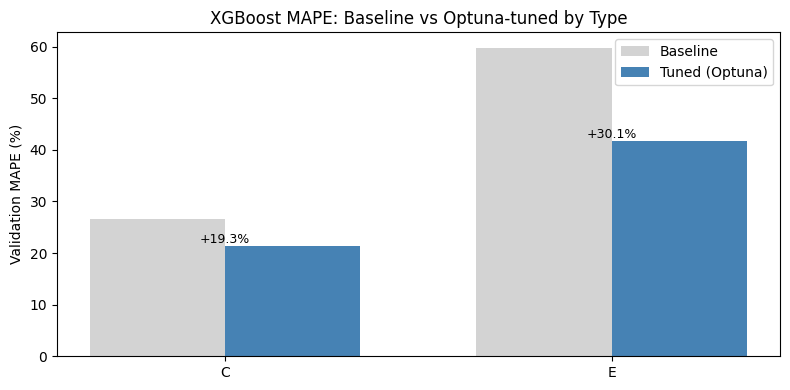


=== 개선 요약 ===
type  baseline_mape  tuned_mape  improvement_pct
   C        26.5127     21.3961            19.30
   E        59.7967     41.7838            30.12


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(types))
w = 0.35
ax.bar(x - w/2, results['baseline_mape'], w, label='Baseline', color='lightgray')
ax.bar(x + w/2, results['tuned_mape'], w, label='Tuned (Optuna)', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(results['type'])
ax.set_ylabel('Validation MAPE (%)')
ax.set_title('XGBoost MAPE: Baseline vs Optuna-tuned by Type')
ax.legend()
for i, row in results.iterrows():
    imp = row['improvement_pct']
    if pd.notna(imp):
        ax.annotate(f'{imp:+.1f}%', (i, row['tuned_mape']), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print('\n=== 개선 요약 ===')
print(results[['type', 'baseline_mape', 'tuned_mape', 'improvement_pct']].to_string(index=False))


### ④ type별 Best 하이퍼파라미터

In [5]:
param_cols = [c for c in results.columns if c.startswith('best_')]
best_params = results[['type'] + param_cols].copy()
best_params.columns = ['type'] + [c.replace('best_', '') for c in param_cols]
display(best_params)


,type,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_alpha,reg_lambda
0,C,550,4,0.027467,0.704846,0.848229,4,0.127981,0.069392
1,E,200,5,0.010095,0.998407,0.712347,6,9.868745,0.009337


### ⑤ 해석 가이드

- **improvement_pct > 0** → 해당 type에서 튜닝이 검증 MAPE를 개선
- **개선이 작거나 음수** → 기본 파라미터가 이미 충분히 좋거나, 3주 검증이 짧아 과적합 가능
- `learning_rate`↓ + `n_estimators`↑ 조합이 자주 나오면 → **세밀한 부스팅** 선호
- type별 best params가 크게 다르면 → **매장 유형별 맞춤 모델** 운영 근거

> 본 장은 **단일 validation window** 기준입니다. 운영 전에는 rolling CV 등으로 재검증하세요.

In [6]:
out = DATA_PROCESSED
results.to_csv(out / 'xgboost_optuna_tuning_results.csv', index=False)
param_cols = [c for c in results.columns if c.startswith('best_')]
best_only = results[['type'] + param_cols].rename(
    columns={c: c.replace('best_', '') for c in param_cols}
)
best_only.to_csv(out / 'xgboost_optuna_best_params_by_type.csv', index=False)
print('저장:', out / 'xgboost_optuna_tuning_results.csv')


저장: C:\Users\kjh\ai-retail-demandforecasting\data\processed\xgboost_optuna_tuning_results.csv
